# Data Introduction
## Files Description

- application_{train|test}.csv
    - This is the main table, broken into two files for Train (with TARGET) and Test (without TARGET).
    - Static data for all applications. One row represents one loan in our data sample.
- bureau.csv
    - All client's previous credits provided by other financial institutions that were reported to Credit Bureau (for clients who have a loan in our sample). 
    - For every loan in our sample, there are as many rows as number of credits the client had in Credit Bureau before the application date.
- bureau_balance.csv
    - Monthly balances of previous credits in Credit Bureau.
    - This table has one row for each month of history of every previous credit reported to Credit Bureau – i.e the table has (#loans in sample * # of relative previous credits * # of months where we have some history observable for the previous credits) rows.
- POS_CASH_balance.csv
    - Monthly balance snapshots of previous POS (point of sales - điểm bán hàng) and cash loans that the applicant had with Home Credit. Đại khái có thể hiểu là các giao dịch chi tiêu sử dụng các khoản vay của Home Credit.
    - This table has one row for each month of history of every previous credit in Home Credit (consumer credit and cash loans) related to loans in our sample – i.e. the table has (#loans in sample * # of relative previous credits * # of months in which we have some history observable for the previous credits) rows.
- credit_card_balance.csv
    - Monthly balance snapshots of previous credit cards that the applicant has with Home Credit.
    - This table has one row for each month of history of every previous credit in Home Credit (consumer credit and cash loans) related to loans in our sample – i.e. the table has (#loans in sample * # of relative previous credit cards * # of months where we have some history observable for the previous credit card) rows.
- previous_application.csv
    - All previous applications for Home Credit loans of clients who have loans in our sample.
    - There is one row for each previous application related to loans in our data sample.
- installments_payments.csv
    - Repayment history for the previously disbursed (đã giải ngân - kiểu là chấp nhận cho vay) credits in Home Credit related to the loans in our sample.
    - There is a) one row for every payment that was made plus b) one row each for missed payment.
    - One row is equivalent to one payment of one instalment (kỳ trả góp) OR one instalment (kỳ trả góp) corresponding to one payment of one previous Home Credit credit related to loans in our sample. Nói chung là thông tin cho 1 kỳ trả góp
- HomeCredit_columns_description.csv: This file contains descriptions for the columns in the various data files.

## Data Schema

Going from top to bottom, the relationships are all one-to-many.

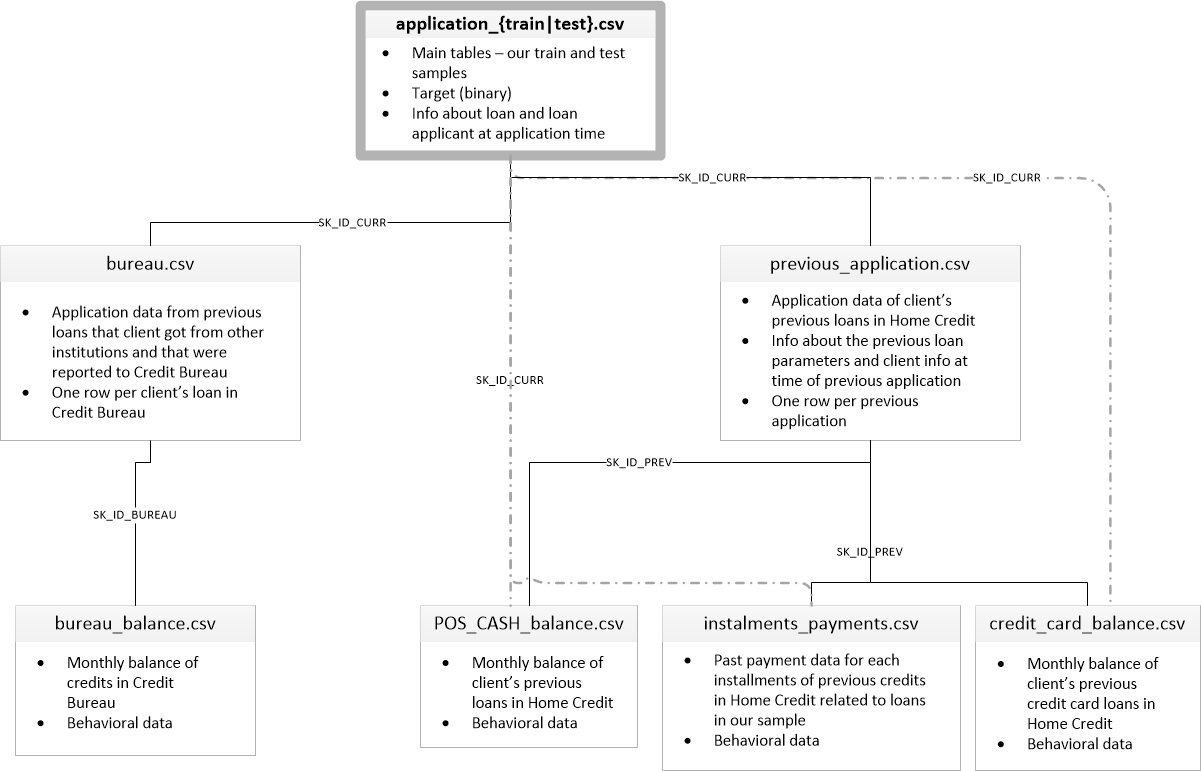

# EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Relationships between tables

In [2]:
application_train = pd.read_csv('data/application_train.csv')
application_test = pd.read_csv('data/application_test.csv')
bureau = pd.read_csv('data/bureau.csv')
bureau_balance = pd.read_csv('data/bureau_balance.csv')
previous_application = pd.read_csv('data/previous_application.csv')
pos_cash = pd.read_csv('data/POS_CASH_balance.csv')
instalments = pd.read_csv('data/installments_payments.csv')
credit_card_balance = pd.read_csv('data/credit_card_balance.csv')

In [ ]:
# application_{train|test} vs bureau
first_train_id = application_test.iloc[0]['SK_ID_CURR']
bureau.groupby('SK_ID_CURR')['SK_ID_BUREAU'].count().head()

# bureau vs bureau_balance
bureau_balance.groupby('SK_ID_BUREAU')['MONTHS_BALANCE'].count()

# application vs pos_cash
pos_cash.groupby(['SK_ID_CURR'])['SK_ID_PREV'].count()

# application vs previous_application
previous_application.groupby('SK_ID_CURR')['SK_ID_PREV'].count()

Index(['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION',
       'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT',
       'AMT_INSTALMENT', 'AMT_PAYMENT'],
      dtype='str')

## application_{train|test}.csv

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

application_train = pd.read_csv('data/application_train.csv')
application_test = pd.read_csv('data/application_test.csv')

print(application_train.columns.tolist())

['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELE

In [2]:
pd.set_option('display.max_rows', None)
application_train.dtypes

SK_ID_CURR                        int64
TARGET                            int64
NAME_CONTRACT_TYPE                  str
CODE_GENDER                         str
FLAG_OWN_CAR                        str
FLAG_OWN_REALTY                     str
CNT_CHILDREN                      int64
AMT_INCOME_TOTAL                float64
AMT_CREDIT                      float64
AMT_ANNUITY                     float64
AMT_GOODS_PRICE                 float64
NAME_TYPE_SUITE                     str
NAME_INCOME_TYPE                    str
NAME_EDUCATION_TYPE                 str
NAME_FAMILY_STATUS                  str
NAME_HOUSING_TYPE                   str
REGION_POPULATION_RELATIVE      float64
DAYS_BIRTH                        int64
DAYS_EMPLOYED                     int64
DAYS_REGISTRATION               float64
DAYS_ID_PUBLISH                   int64
OWN_CAR_AGE                     float64
FLAG_MOBIL                        int64
FLAG_EMP_PHONE                    int64
FLAG_WORK_PHONE                   int64


### String columns

In [2]:
str_cols = application_train.dtypes[application_train.dtypes == 'str'].index.tolist()
str_cols

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [4]:
num_rows = application_train.shape[0]

for col in str_cols:
    print(f'Column: {col}')
    print(f'NaN values: {application_train[col].isna().sum() / num_rows} ({application_train[col].isna().sum()} / {num_rows})')
    print(f'Number of unique values: {application_train[col].nunique()}')
    print(f'Unique values: {application_train[col].unique().tolist()}')
    # print(application_train[col].value_counts())
    print('------------------------')

Column: NAME_CONTRACT_TYPE
NaN values: 0.0 (0 / 307511)
Number of unique values: 2
Unique values: ['Cash loans', 'Revolving loans']
------------------------
Column: CODE_GENDER
NaN values: 0.0 (0 / 307511)
Number of unique values: 3
Unique values: ['M', 'F', 'XNA']
------------------------
Column: FLAG_OWN_CAR
NaN values: 0.0 (0 / 307511)
Number of unique values: 2
Unique values: ['N', 'Y']
------------------------
Column: FLAG_OWN_REALTY
NaN values: 0.0 (0 / 307511)
Number of unique values: 2
Unique values: ['Y', 'N']
------------------------
Column: NAME_TYPE_SUITE
NaN values: 0.004201475719567756 (1292 / 307511)
Number of unique values: 7
Unique values: ['Unaccompanied', 'Family', 'Spouse, partner', 'Children', 'Other_A', nan, 'Other_B', 'Group of people']
------------------------
Column: NAME_INCOME_TYPE
NaN values: 0.0 (0 / 307511)
Number of unique values: 8
Unique values: ['Working', 'State servant', 'Commercial associate', 'Pensioner', 'Unemployed', 'Student', 'Businessman', 'Ma

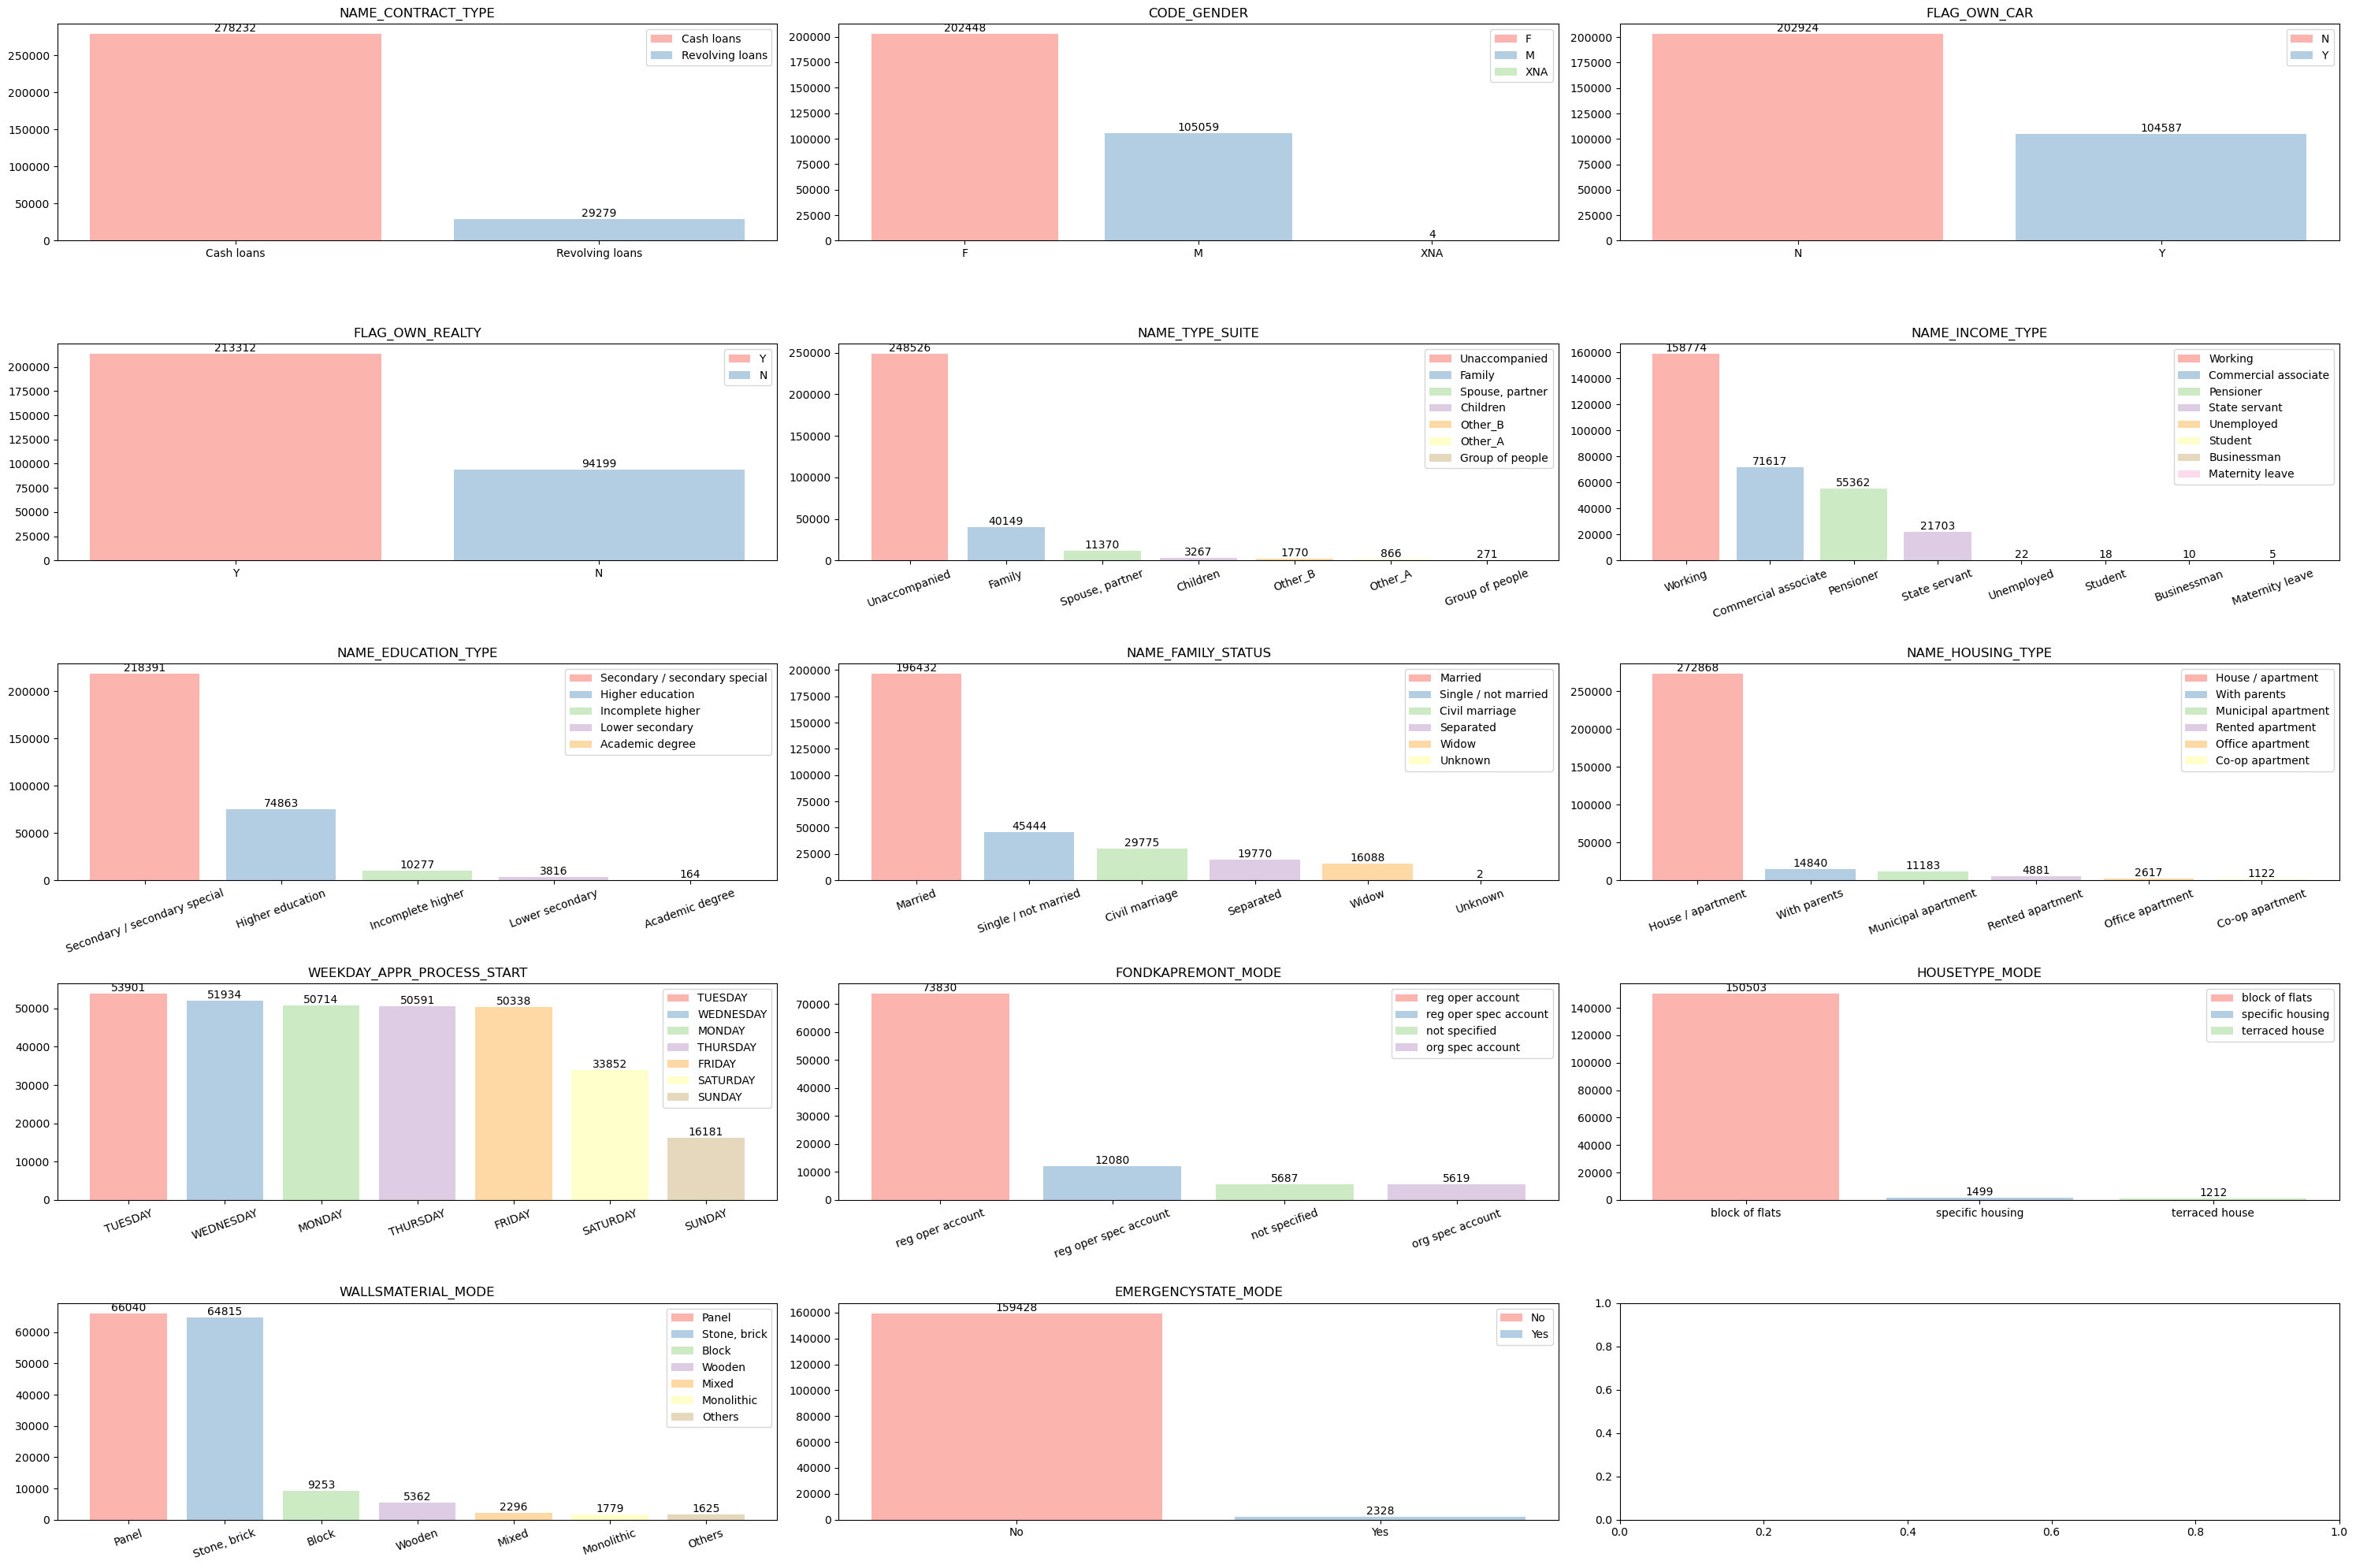

In [3]:
draw_str_cols = str_cols.copy()
draw_str_cols.remove('OCCUPATION_TYPE')
draw_str_cols.remove('ORGANIZATION_TYPE')

fig, ax = plt.subplots(5, 3, figsize=(30, 20))
cmap = plt.get_cmap('Pastel1')

for i, col in enumerate(draw_str_cols):
    col_counts = application_train[col].value_counts()
    bar_colors = [cmap(i) for i in np.arange(len(col_counts))]
    current_ax = ax[i // 3, i % 3].bar(col_counts.index, col_counts.values, color=bar_colors)
    ax[i // 3, i % 3].bar_label(current_ax)
    ax[i // 3, i % 3].set_title(col)
    ax[i // 3, i % 3].legend(current_ax, col_counts.index)
    if len(col_counts.index) > 3:
        ax[i // 3, i % 3].tick_params(axis='x', rotation=20)
    # print(col_counts.index)

plt.tight_layout()
plt.show()

### Int columns

In [19]:
int_cols = application_train.dtypes[application_train.dtypes == 'int64'].index.tolist()
int_cols

['SK_ID_CURR',
 'TARGET',
 'CNT_CHILDREN',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_ID_PUBLISH',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_3',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_5',
 'FLAG_DOCUMENT_6',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_8',
 'FLAG_DOCUMENT_9',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_11',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_13',
 'FLAG_DOCUMENT_14',
 'FLAG_DOCUMENT_15',
 'FLAG_DOCUMENT_16',
 'FLAG_DOCUMENT_17',
 'FLAG_DOCUMENT_18',
 'FLAG_DOCUMENT_19',
 'FLAG_DOCUMENT_20',
 'FLAG_DOCUMENT_21']

In [33]:
# Check if there is overlapping IDs
print(f"Check IDs: {application_train['SK_ID_CURR'].nunique() == application_train.shape[0]}")

# Check targets
print(f"Check targets: {application_train['TARGET'].unique()}")

# Check flag documents
flag_docs = [i for i in int_cols if ('FLAG_' in i or 'REG_' in i or 'LIVE_' in i)]
for col in flag_docs:
    if sorted(application_train[col].unique().tolist()) == [0, 1]:
        continue
    else:
        print(f"Check flag column {i}: False")
        print(application_train[col].unique())

# Check region ratings
for col in ['REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY']:
    if sorted(application_train[col].unique().tolist()) == [1, 2, 3]:
        continue
    else:
        print(f"Check column {i}: False")
        print(application_train[col].unique())

# Check count children
print(application_train['CNT_CHILDREN'].value_counts())

# Check HOUR_APPR_PROCESS_START
print(f'Check applied hour: {sorted(application_train['HOUR_APPR_PROCESS_START'].unique().tolist())}')

# Check DAYS_BIRTH 

# Check DAYS_EMPLOYED

# Check DAYS_ID_PUBLISH

Check IDs: True
Check targets: [1 0]
CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
14         3
8          2
9          2
12         2
10         2
19         2
11         1
Name: count, dtype: int64
Check applied hour: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


### Float columns

### Correlations between columns
Phải kiểm tra xem liệu có cột nào correlate, các cột nào mà ý nghĩa vớ vẩn thì bỏ đi

# Data Preprocessing Pipeline

- **String Columns**:   
    - Hot Encoding columns: NAME_CONTRACT_TYPE, NAME_TYPE_SUITE, NAME_INCOME_TYPE, NAME_FAMILY_STATUS, NAME_HOUSING_TYPE, FONDKAPREMONT_MODE, HOUSETYPE_MODE, WALLSMATERIAL_MODE
    - Ordered columns:
        - CODE_GENDER: {'F': 0, 'M': 1, 'XNA': 2}
        - FLAG_OWN_CAR: {'N': 0, 'Y': 1}
        - FLAG_OWN_REALTY: {'N': 0, 'Y': 1}
        - NAME_EDUCATION_TYPE: {'Lower secondar': 0, 'Secondary / secondary special': 1, 'Incomplete higher': 2, 'Higher education': 3, 'Academic degree': 4}
        - WEEKDAY_APPR_PROCESS_START: {'MONDAY': 0, 'TUESDAY': 1, 'WEDNESDAY': 2, 'THURSDAY': 3, 'FRIDAY': 4, 'SATURDAY': 5, 'SUNDAY': 6}
        - EMERGENCYSTATE_MODE: {'No': 0, 'Yes': 1}